In [39]:
import json
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy as scs
import xarray as xr

DIR_REPO = Path.cwd().parents[1]
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))
print(DIR_REPO)

d:\WORK\Salvador\repo\A1_OUinp


In [40]:
EXP_LABEL = (
    'exp_pre_L2_post_L2_nseed_5_npre_5_t_5.0_20.0_tri_t0_5000_T_7500_rmax_10xbkg_500_ictrl_wmult_0.25_ee_0.5'
)
CFG_PARAM_FIELDS = {'pop_pre': 'pop_pre', 'seed': 'seed_main'}

# Time interval of spike extraction
spike_t_limits = (1, None)

# Params of rate dynamics
dt_bin = 2e-3
tau_smooth = 10e-3

# Per-dimension chunk sizes for the rate dynamics nc-file
rate_chunks = {'pop_pre': 1, 'seed': 1}

#dirpath_exp = DIR_REPO / 'exp_results' / EXP_LABEL
dirpath_exp = Path('X:') / EXP_LABEL
dirpath_cfg = dirpath_exp / 'cfg'
dirpath_work = dirpath_exp / 'combined'
dirpath_cache = dirpath_work / 'data_proc'
dirpath_res = dirpath_work / 'results'

os.makedirs(dirpath_cache, exist_ok=True)
os.makedirs(dirpath_res, exist_ok=True)

In [18]:
list(dirpath_cache.rglob('*'))

[WindowsPath('X:exp_pre_L2_post_L2_nseed_5_npre_5_t_5.0_20.0_tri_t0_5000_T_7500_rmax_10xbkg_500_ictrl_wmult_0.25_ee_0.5/combined/data_proc/rates_dt_0.002_tau_0.01.nc')]

In [19]:
rates_cache_path = dirpath_cache / f'rates_dt_{dt_bin}_tau_{tau_smooth}.nc'

rates_xr = xr.open_dataarray(rates_cache_path, chunks={})
rates_xr

<xarray.DataArray (pop_pre: 5, seed: 5, pop: 10, time: 9500)>
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(5, 5, 10, 9500), dtype=float64, chunksize=(5, 5, 10, 9500), chunktype=numpy.ndarray>
Coordinates:
  * pop_pre  (pop_pre) object 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * seed     (seed) int64 1000 1001 1002 1003 1004
  * pop      (pop) object 'IT2' 'PV2' 'SOM2' ... 'SOM2frz' 'VIP2frz' 'NGF2frz'
  * time     (time) float64 1.0 1.002 1.004 1.006 ... 19.99 19.99 20.0 20.0
    job_id   (pop_pre, seed) int64 dask.array<chunksize=(5, 5), meta=np.ndarray>
Attributes:
    time_units:  s
    cache_info:  __json__:{"cache_id":"7f028c381b13","cache_version":1,"param...
    proc_steps:  __json__:[{"name":"collect_batch_rates_from_spike_data","par...

In [20]:
# Read first config
fname_job_cfg_templ = 'cfg_00000_*.json'
cfg_paths = sorted(dirpath_cfg.glob(fname_job_cfg_templ))
with cfg_paths[0].open('r', encoding='utf-8') as f:
    cfg0 = json.load(f)['simConfig']

# Target rates
r_target = cfg0['target_rates']

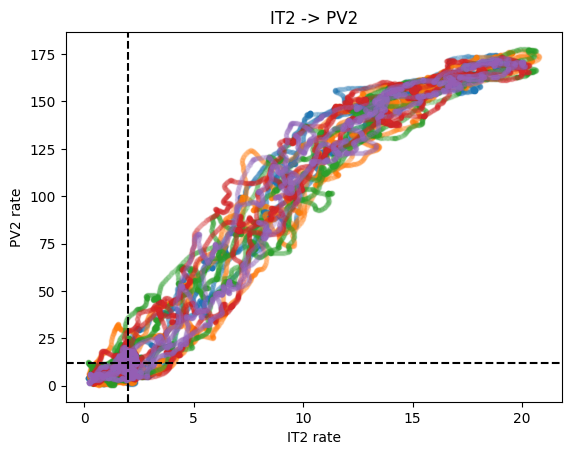

In [23]:
pop_pre = 'IT2'

pops_post = [pop for pop in rates_xr.pop.values if 'frz' not in pop]

R_pre = rates_xr.sel(pop_pre=pop_pre, pop=f'{pop_pre}frz').compute()
R_post = rates_xr.sel(pop_pre=pop_pre, pop=pops_post).compute()

# Moving-average smoothing over time
smooth_win_s = 0.2
smooth_win_n = max(1, int(round(smooth_win_s / dt_bin)))
R_pre_sm = R_pre.rolling(time=smooth_win_n, center=True, min_periods=1).mean()
R_post_sm = R_post.rolling(time=smooth_win_n, center=True, min_periods=1).mean()

#mask = R_pre_sm < 8
#R_pre_sm = R_pre_sm.where(mask)
#R_post_sm = R_post_sm.where(mask)

pop_post = 'PV2'

r0_pre = r_target[pop_pre]
r0_post = r_target[pop_post]

plt.figure()
for seed in R_pre_sm.seed.values:
    plt.plot(R_pre_sm.sel(seed=seed),
             R_post_sm.sel(seed=seed).sel(pop=pop_post),
             '.', alpha=0.1)
plt.axhline(r0_post, color='k', linestyle='--')
plt.axvline(r0_pre, color='k', linestyle='--')
plt.xlabel(f'{pop_pre} rate')
plt.ylabel(f'{pop_post} rate')
plt.title(f'{pop_pre} -> {pop_post}')
plt.show()

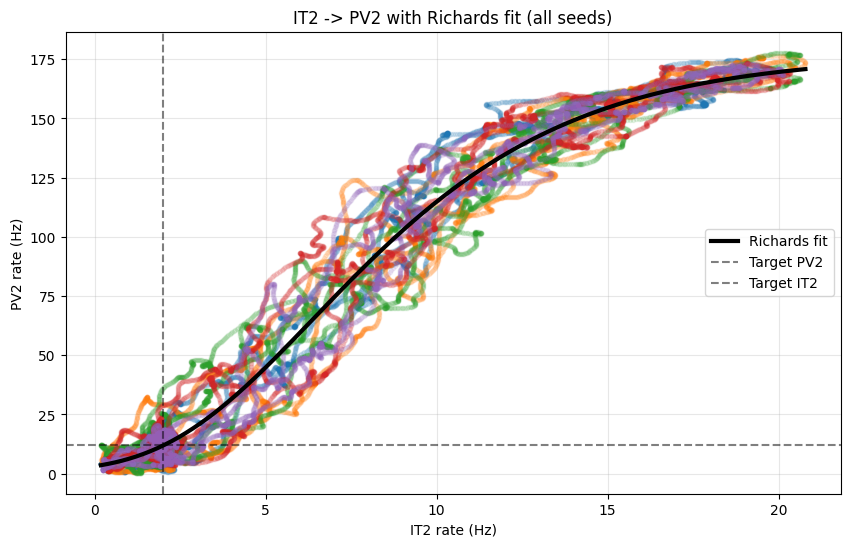

In [25]:
from scipy.optimize import curve_fit

# Collapse all seeds together
X_all = R_pre_sm.values.flatten()
Y_all = R_post_sm.sel(pop=pop_post).values.flatten()

# Remove NaN values
mask_valid = ~(np.isnan(X_all) | np.isnan(Y_all))
X_fit = X_all[mask_valid]
Y_fit = Y_all[mask_valid]

# Define Richards function: f(x) = A + (K - A) / (1 + exp(-B * (x - M))) ** (1/nu)
def richards(x, A, K, B, M, nu):
    return A + (K - A) / (1 + np.exp(-B * (x - M))) ** (1/nu)

# Initial parameter guesses
A_init = np.min(Y_fit)  # lower asymptote
K_init = np.max(Y_fit)  # upper asymptote
B_init = 1.0            # growth rate
M_init = np.median(X_fit)  # inflection point
nu_init = 1.0           # shape parameter

p0 = [A_init, K_init, B_init, M_init, nu_init]

# Fit the Richards function
popt, pcov = curve_fit(richards, X_fit, Y_fit, p0=p0, maxfev=10000)
A_fit, K_fit, B_fit, M_fit, nu_fit = popt


# Plot the data and fit
plt.figure(figsize=(10, 6))

# Plot all seed data points
for seed in R_pre_sm.seed.values:
    plt.plot(R_pre_sm.sel(seed=seed),
                R_post_sm.sel(seed=seed).sel(pop=pop_post),
                '.', alpha=0.1)

# Plot the fitted Richards curve
X_range = np.linspace(X_fit.min(), X_fit.max(), 300)
Y_richards = richards(X_range, *popt)
plt.plot(X_range, Y_richards, 'k-', linewidth=3, label='Richards fit')

# Add reference lines
plt.axhline(r0_post, color='k', linestyle='--', alpha=0.5, label=f'Target {pop_post}')
plt.axvline(r0_pre, color='k', linestyle='--', alpha=0.5, label=f'Target {pop_pre}')

plt.xlabel(f'{pop_pre} rate (Hz)')
plt.ylabel(f'{pop_post} rate (Hz)')
plt.title(f'{pop_pre} -> {pop_post} with Richards fit (all seeds)')
plt.legend()
plt.show()

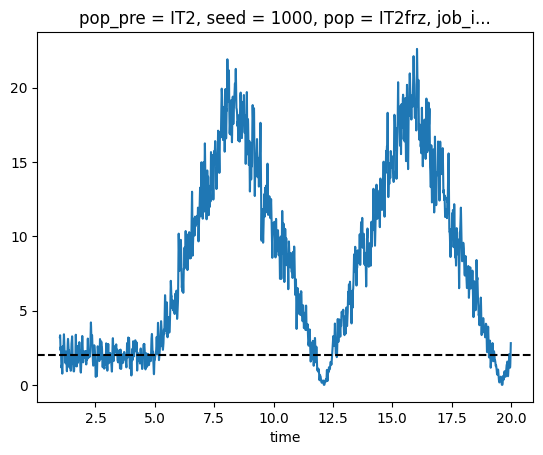

In [22]:
pop_dyn = 'IT2'
pop_pre = 'IT2'
R_pre = rates_xr.sel(pop_pre=pop_dyn, pop=f'{pop_pre}frz').isel(seed=0).compute()
r0_pre = r_target[pop_pre]

R_pre.plot()
plt.axhline(r0_pre, color='k', linestyle='--')

In [27]:
import json

# Load Richards coefficients from file
richards_coeff_path = dirpath_res / 'richards_coefficients.json'
with richards_coeff_path.open('r', encoding='utf-8') as f:
    richards_coeffs = json.load(f)

# Get all pre and post populations
pops_pre = list(richards_coeffs.keys())
pops_post_all = list(set([pop_post for coeffs_dict in richards_coeffs.values() for pop_post in coeffs_dict.keys()]))

# Initialize the weight matrix W
W = np.zeros((len(pops_pre), len(pops_post_all)))

# Compute derivative of Richards function: dR/dx = (K - A) * B * exp(-B(x-M)) / (nu * (1 + exp(-B(x-M)))^(1 + 1/nu))
def richards_derivative(x, A, K, B, M, nu):
    exp_term = np.exp(-B * (x - M))
    base = (1 + exp_term)
    return (K - A) * B * exp_term / (nu * base ** (1 + 1/nu))

# Fill the weight matrix
for i, pop_pre in enumerate(pops_pre):
    r_pre_target = r_target[pop_pre]    
    for j, pop_post in enumerate(pops_post_all):
        if pop_post in richards_coeffs[pop_pre]:
            # Extract Richards coeffs
            coeffs = richards_coeffs[pop_pre][pop_post]
            A, K, B, M, nu = coeffs['A'], coeffs['K'], coeffs['B'], coeffs['M'], coeffs['nu']            
            # Compute derivative at target rate
            dR_dr = richards_derivative(r_pre_target, A, K, B, M, nu)
            W[i, j] = dR_dr
        else:
            W[i, j] = 0.0

# Convert W to xarray DataArray
W = xr.DataArray(
    W, dims=['pop_pre', 'pop_post'],
    coords={'pop_pre': pops_pre, 'pop_post': pops_post_all},
)
W


C:\Users\aleks\AppData\Local\Temp\ipykernel_11240\2770661971.py:19: RuntimeWarning: overflow encountered in scalar power
  return (K - A) * B * exp_term / (nu * base ** (1 + 1/nu))
C:\Users\aleks\AppData\Local\Temp\ipykernel_11240\2770661971.py:17: RuntimeWarning: overflow encountered in exp
  exp_term = np.exp(-B * (x - M))
C:\Users\aleks\AppData\Local\Temp\ipykernel_11240\2770661971.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (K - A) * B * exp_term / (nu * base ** (1 + 1/nu))


<xarray.DataArray (pop_pre: 5, pop_post: 5)>
array([[ 4.15872428e-002,  8.33886179e-001,  1.65007972e+000,
         6.91721938e+000,  1.07587457e-001],
       [-1.90143147e-002,  4.25288174e-049, -1.69253968e-037,
         0.00000000e+000, -6.48196156e-056],
       [-4.22109827e-003, -2.50969226e-002,              nan,
        -2.61595317e-157, -0.00000000e+000],
       [-1.54837207e-002, -1.15896851e-001, -0.00000000e+000,
        -1.02194693e-001, -3.11491482e-002],
       [-0.00000000e+000, -0.00000000e+000,  0.00000000e+000,
         0.00000000e+000, -9.83165844e-015]])
Coordinates:
  * pop_pre   (pop_pre) <U4 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * pop_post  (pop_post) <U4 'IT2' 'VIP2' 'SOM2' 'PV2' 'NGF2'

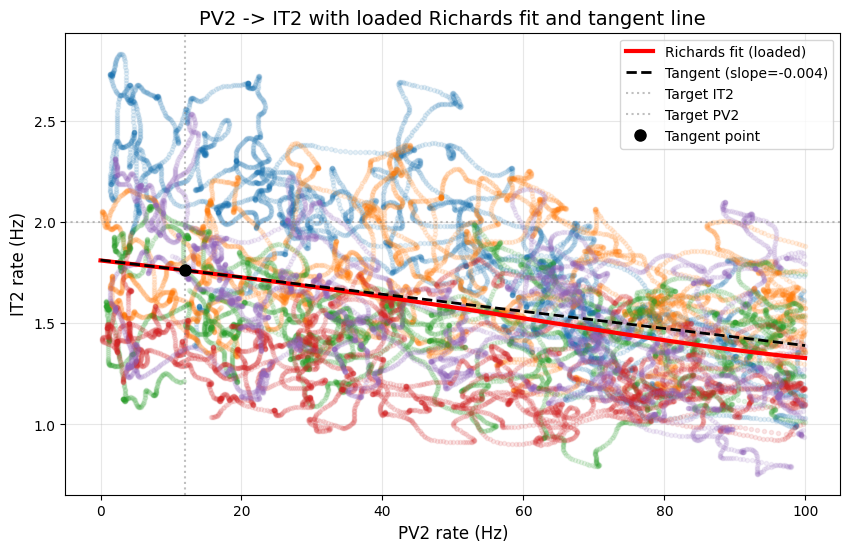

Derivative (weight) W[PV2, IT2] = -0.0042
Richards parameters: A=2.322, K=1.248, B=0.062, M=97.759, nu=8.128


In [32]:
# Plot example using loaded coefficients and tangent line from W
pop_pre = 'PV2'
pop_post = 'IT2'

# Use time range
t_lim_used = (5, None)

# Get coefficients from loaded data
coeffs = richards_coeffs[pop_pre][pop_post]
A, K, B, M, nu = [coeffs[v] for v in ['A', 'K', 'B', 'M', 'nu']]

# Get target rates
r0_pre = r_target[pop_pre]
r0_post = r_target[pop_post]

# Get derivative (weight) from W matrix
i_pre = list(W.pop_pre.values).index(pop_pre)
j_post = list(W.pop_post.values).index(pop_post)
dR_dr = W.values[i_pre, j_post]

# Get smoothed data (reuse from cell 6)
R_pre = rates_xr.sel(
    pop_pre=pop_pre, pop=f'{pop_pre}frz', time=slice(*t_lim_used)
).compute()
R_post = rates_xr.sel(
    pop_pre=pop_pre, pop=pops_post, time=slice(*t_lim_used)
).compute()

smooth_win_s = 0.2
smooth_win_n = max(1, int(round(smooth_win_s / dt_bin)))
R_pre_sm = R_pre.rolling(time=smooth_win_n, center=True, min_periods=1).mean()
R_post_sm = R_post.rolling(time=smooth_win_n, center=True, min_periods=1).mean()

mask = R_pre_sm < 100
R_pre_sm = R_pre_sm.where(mask)
R_post_sm = R_post_sm.where(mask)

# Create plot
plt.figure(figsize=(10, 6))

# Plot all seed data points
for seed in R_pre_sm.seed.values:
    plt.plot(R_pre_sm.sel(seed=seed),
             R_post_sm.sel(seed=seed).sel(pop=pop_post),
             '.', alpha=0.1)

# Plot the Richards curve using loaded coefficients
X_range = np.linspace(0, R_pre_sm.max().values, 300)
Y_richards = richards(X_range, A, K, B, M, nu)
plt.plot(X_range, Y_richards, 'r-', linewidth=3, label='Richards fit (loaded)')

# Compute the actual rate at target
r_post_at_target = richards(r0_pre, A, K, B, M, nu)

# Plot tangent line at target rate: y = dR_dr * (x - r0_pre) + r_post_at_target
X_tangent = np.linspace(0, R_pre_sm.max().values, 100)
Y_tangent = dR_dr * (X_tangent - r0_pre) + r_post_at_target
plt.plot(X_tangent, Y_tangent, 'k--', linewidth=2, label=f'Tangent (slope={dR_dr:.3f})')

# Add reference lines for target rates
plt.axhline(r0_post, color='gray', linestyle=':', alpha=0.5, label=f'Target {pop_post}')
plt.axvline(r0_pre, color='gray', linestyle=':', alpha=0.5, label=f'Target {pop_pre}')

# Mark the tangent point
plt.plot(r0_pre, r_post_at_target, 'ko', markersize=8, label='Tangent point')

plt.xlabel(f'{pop_pre} rate (Hz)', fontsize=12)
plt.ylabel(f'{pop_post} rate (Hz)', fontsize=12)
plt.title(f'{pop_pre} -> {pop_post} with loaded Richards fit and tangent line', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Derivative (weight) W[{pop_pre}, {pop_post}] = {dR_dr:.4f}")
print(f"Richards parameters: A={A:.3f}, K={K:.3f}, B={B:.3f}, M={M:.3f}, nu={nu:.3f}")


In [34]:
W.round(3)

<xarray.DataArray (pop_pre: 5, pop_post: 5)>
array([[ 4.200e-02,  8.340e-01,  1.650e+00,  6.917e+00,  1.080e-01],
       [-1.900e-02,  0.000e+00, -0.000e+00,  0.000e+00, -0.000e+00],
       [-4.000e-03, -2.500e-02,        nan, -0.000e+00, -0.000e+00],
       [-1.500e-02, -1.160e-01, -0.000e+00, -1.020e-01, -3.100e-02],
       [-0.000e+00, -0.000e+00,  0.000e+00,  0.000e+00, -0.000e+00]])
Coordinates:
  * pop_pre   (pop_pre) <U4 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * pop_post  (pop_post) <U4 'IT2' 'VIP2' 'SOM2' 'PV2' 'NGF2'

In [36]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

L2_POPS = ['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2']
L4_POPS = ['ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4', 'NGF4']
CTX_POPS = PYR_POPS + PV_POPS + SOM_POPS + VIP_POPS + NGF_POPS

len(CTX_POPS) * 5

180

In [41]:
W = xr.open_dataarray(dirpath_res / 'wmat_tau_0.3.nc')
W

<xarray.DataArray (pop_pre: 5, pop_post: 5)>
[25 values with dtype=float64]
Coordinates:
  * pop_pre   (pop_pre) object 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * pop_post  (pop_post) object 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2'

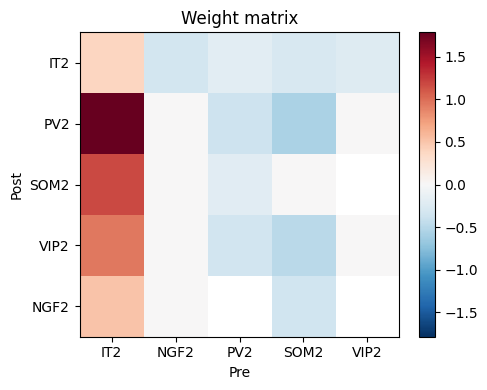

In [57]:
plt.figure(figsize=(5, 4))
Wvis = (np.sign(W) * (np.abs(W) ** 0.3)).values.T
vmax = np.nanmax(np.abs(Wvis))
plt.imshow(Wvis, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.yticks(range(len(W.pop_post)), W.pop_post.values, rotation=0)
plt.xticks(range(len(W.pop_pre)), W.pop_pre.values)
plt.ylabel('Post')
plt.xlabel('Pre')
plt.title('Weight matrix')
plt.tight_layout()
plt.show()


In [62]:
import numpy.linalg as lin

W = W.fillna(0)
lin.det(W.values)


8.990332271405945e-22

In [77]:
np.set_printoptions(suppress=True)
print((W.T).round(4))


<xarray.DataArray (pop_post: 5, pop_pre: 5)>
array([[ 0.0424, -0.0236, -0.004 , -0.0156, -0.0072],
       [ 6.924 ,  0.    , -0.0363, -0.1446,  0.    ],
       [ 1.7326, -0.    , -0.0044, -0.    ,  0.    ],
       [ 0.8302,  0.    , -0.0272, -0.0842, -0.    ],
       [ 0.1077, -0.    ,  0.    , -0.0333,  0.    ]])
Coordinates:
  * pop_pre   (pop_pre) object 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * pop_post  (pop_post) object 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2'


In [94]:
W_ = W.T.copy()
W_[0, 0] *= 30
W_[0, 1] *= 10
lin.inv(np.eye(5) - W_).round(3)

array([[ 0.746, -0.176,  0.003,  0.013, -0.005],
       [ 5.038, -0.189, -0.012, -0.046, -0.036],
       [ 1.286, -0.303,  1.001,  0.022, -0.009],
       [ 0.539, -0.127, -0.023,  0.932, -0.004],
       [ 0.062, -0.015,  0.001, -0.03 ,  1.   ]])

In [99]:
W.T

<xarray.DataArray (pop_post: 5, pop_pre: 5)>
array([[ 0.04239311, -0.02359319, -0.00403914, -0.01555832, -0.00719012],
       [ 6.92404506,  0.        , -0.03630152, -0.14462526,  0.        ],
       [ 1.73256962, -0.        , -0.00440941, -0.        ,  0.        ],
       [ 0.83017328,  0.        , -0.02720315, -0.08420583, -0.        ],
       [ 0.10773431, -0.        ,  0.        , -0.03333384,  0.        ]])
Coordinates:
  * pop_pre   (pop_pre) object 'IT2' 'NGF2' 'PV2' 'SOM2' 'VIP2'
  * pop_post  (pop_post) object 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2'

In [101]:
fpath_conn = DIR_REPO / 'conn' / 'conn.nc'
C = xr.load_dataset(fpath_conn)

# Keep only populations that are in W
C = C.sel(pop_pre=[p for p in C.pop_pre.values if p in W.pop_pre.values],
          pop_post=[p for p in C.pop_post.values if p in W.pop_post.values])
C

<xarray.Dataset>
Dimensions:   (pop_post: 5, pop_pre: 5)
Coordinates:
  * pop_post  (pop_post) object 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2'
  * pop_pre   (pop_pre) object 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2'
Data variables:
    pmat      (pop_post, pop_pre) float64 0.1971 0.5523 ... 0.2658 0.03382
    wmat      (pop_post, pop_pre) float64 0.36 0.48 0.31 0.48 ... 0.52 0.41 0.37
    N         (pop_pre) int32 338 13 5 16 11
    r         (pop_pre) float64 2.0 12.0 6.0 7.0 1.0

In [129]:
def _to_list(x):
    if x is None:
        return []
    if np.isscalar(x):
        return [x]
    return list(x)


def plot_mat(ax, da, title, sep_x=None, sep_y=None, transpose=True, yinv=True, 
             show_xlabel=True, show_ylabel=True, show_xticklabels=True, show_yticklabels=True):
    if transpose:
        da = da.transpose('pop_post', 'pop_pre')
    else:
        da = da.transpose('pop_pre', 'pop_post')
    vmax = float(np.nanmax(np.abs(da.values)))
    im = ax.imshow(da.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax)
    if yinv:
        ax.invert_yaxis()

    pops_post = list(da.pop_post.values)
    pops_pre = list(da.pop_pre.values)

    if transpose:
        pops_x = pops_pre
        pops_y = pops_post
        xlabel_text = 'Pre'
        ylabel_text = 'Post'
    else:
        pops_x = pops_post
        pops_y = pops_pre
        xlabel_text = 'Post'
        ylabel_text = 'Pre'

    ax.set_xticks(range(len(pops_x)))
    if show_xticklabels:
        ax.set_xticklabels(pops_x, rotation=45, ha='right')
    else:
        ax.set_xticklabels([])
        
    ax.set_yticks(range(len(pops_y)))
    if show_yticklabels:
        ax.set_yticklabels(pops_y)
    else:
        ax.set_yticklabels([])

    if show_xlabel:
        ax.set_xlabel(xlabel_text)
    if show_ylabel:
        ax.set_ylabel(ylabel_text)

    ax.set_title(title)

    for sep_x_ in _to_list(sep_x):
        ax.axvline(x=sep_x_ - 0.5, color='k', lw=2)
    for sep_y_ in _to_list(sep_y):
        ax.axhline(y=sep_y_ - 0.5, color='k', lw=2)


def plot_conn(pops_pre=None, pops_post=None, pops_inh=None,
              sep_x=None, sep_y=None, transpose=True, yinv=True):
    if pops_pre is None:
        pops_pre = C['pop_pre'].values
    if pops_post is None:
        pops_post = C['pop_post'].values
    pmat = C['pmat'].sel(pop_post=pops_post, pop_pre=pops_pre)
    wmat = C['wmat'].sel(pop_post=pops_post, pop_pre=pops_pre)
    N = C['N'].sel(pop_pre=pops_pre)
    r = C['r'].sel(pop_pre=pops_pre)

    # Sign inhibitory presynaptic populations
    if pops_inh is not None:
        sign = xr.DataArray(
            np.where([p in pops_inh for p in pops_pre], -1.0, 1.0),
            dims='pop_pre',
            coords={'pop_pre': pops_pre},
        )
        wmat = wmat * sign   # multiplication preserves dim order
    
    kpow = 0.3
    def pow(x, k):
        return np.sign(x) * (np.abs(x) ** k)

    pw   = pmat * wmat
    pw_N = pow(pw * N, kpow)
    pw_Nr = pow(pw * N * r, kpow)
    
    # Prepare W matrix
    W_vis = pow(W, kpow)

    fig, axes = plt.subplots(2, 3, figsize=(8, 4.5))
    nrows, ncols = 2, 3
    data_list = [pmat, wmat, pw, pw_N, pw_Nr, W_vis]
    titles = ['pmat', 'wmat', 'p*w', 'p*w*N', 'p*w*N*r', 'W']
    
    for idx, (ax, da, title) in enumerate(zip(axes.ravel(), data_list, titles)):
        row = idx // ncols
        col = idx % ncols
        show_xlabel = (row == nrows - 1)  # Only bottom row
        show_ylabel = (col == 0)  # Only left column
        show_xticklabels = (row == nrows - 1)  # Only bottom row
        show_yticklabels = (col == 0)  # Only left column
        plot_mat(ax, da, title, sep_x=sep_x, sep_y=sep_y,
                 transpose=transpose, yinv=yinv,
                 show_xlabel=show_xlabel, show_ylabel=show_ylabel,
                 show_xticklabels=show_xticklabels, show_yticklabels=show_yticklabels)
    
    plt.subplots_adjust(hspace=0.25, wspace=0.2)
    plt.show()


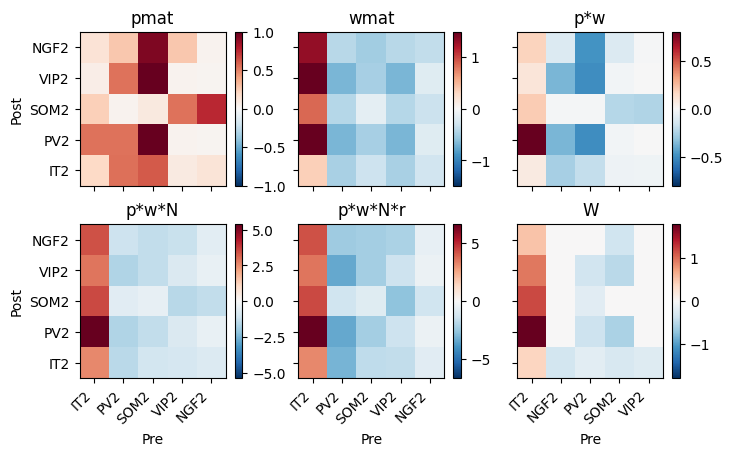

In [130]:
plot_conn(pops_inh=['PV2', 'SOM2', 'VIP2', 'NGF2'])